# Module 1: Clustering

This notebook contains the preparation of the final dataset (`dataset_0.csv`) for the clustering algorithms, as well as the clustering itself.

## 1) Load Packages + Data

In [59]:
#load packages
import pandas as pd 
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import PowerTransformer
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
import prince

In [60]:
#load data
df = pd.read_csv("../../data/final_datasets/dataset_0.csv", dtype={"plr_id": str})
df.head(3)

,plr_id,plr_name,bez,re_miete_niveau,re_miete_trend,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_dichte_all,soc_young_to_middle_adult_share_2025,...,com_share_min_30y_slope,com_share_min_40y_slope,com_share_solo_slope,com_share_10plus_slope,com_gastro_share_slope,com_entry_rate_slope,com_exit_rate_slope,com_n_gastro,re_altbau_share,re_neubau_share
0,01100101,Stülerstraße,01 - Mitte,22.7,2.142,3.050847,3890.584913,-0.326098,10.653753,0.460,...,0.001367,-0.000276,0.024083,0.002754,0.003153,-0.002800,0.001395,13.000000,0.118160,0.102663
1,01100102,Großer Tiergarten,01 - Mitte,20.3,1.059,4.557180,3440.019389,-0.426678,24.075666,0.479,...,0.003015,0.001063,0.028592,0.002506,0.004856,-0.000930,-0.000664,129.333333,0.228719,0.297506
2,01100103,Lützowstraße,01 - Mitte,23.0,1.356,1.863997,3541.826020,-0.440097,16.223680,0.455,...,0.001498,0.001101,0.032530,-0.001222,0.000177,-0.001019,0.000103,43.833333,0.323783,0.130135


In [61]:
df.shape

(527, 45)

In [62]:
#define id columns and feature columns
id_cols = ["plr_id", "plr_name", "bez"]
feat_cols = [c for c in df.columns if c not in id_cols]

## 2) Imputation

There are still two PLR's with missing columns. These will be imputed using **K-Nearest Neighbors (KNN) imputation**. Each sample’s missing values are imputed using the mean value from n_neighbors nearest neighbors. Two samples are close if the features that neither is missing are close. More info can be found in the sklearn documentation (https://scikit-learn.org/stable/modules/generated/sklearn.impute.KNNImputer.html).

In [63]:
# per-PLR list of missing columns (most readable)
mask = df[feat_cols].isna().any(axis=1)
for _, r in df.loc[mask].iterrows():
    missing = [c for c in feat_cols if pd.isna(r[c])]
    print(f"{r['plr_id']} — {r['plr_name']}: {', '.join(missing)}")

07200412 — Schöneberger Linse: re_brw_niveau, re_brw_trend
11300723 — Bornitzstraße: re_miete_trend


In [64]:
# keep plr_id retrievable; work on a feature-only matrix
X = df[feat_cols].copy()
ids = df[id_cols].copy()

# 1) impute the 3 gaps (2 PLRs) from similar PLRs
X_imp = pd.DataFrame(
    KNNImputer(n_neighbors=3).fit_transform(X),
    columns=feat_cols, index=df.index,
)

# sanity checks
print(len(feat_cols), "Features |", X_imp.shape, "| verbleibende NaN:", int(X_imp.isna().sum().sum()))

42 Features | (527, 42) | verbleibende NaN: 0


In [65]:
X_imp.columns

Index(['re_miete_niveau', 're_miete_trend', 're_leerstandsquote',
       're_brw_niveau', 're_brw_trend', 're_dichte_all',
       'soc_young_to_middle_adult_share_2025',
       'soc_young_to_middle_adult_share_change_2021_2025',
       'soc_single_person_hh_share_change_2021_2024',
       'soc_average_household_size_2024',
       'soc_average_household_size_change_2021_2024',
       'soc_households_without_minor_children_share_change_2021_2024',
       'soc_internal_migration_volume_rate_2025',
       'soc_internal_migration_volume_rate_change_2021_2025',
       'soc_internal_net_migration_rate_2025',
       'soc_internal_net_migration_rate_change_2021_2025',
       'soc_unemployment_share_change_2020_2024',
       'soc_transfer_benefit_share_2024',
       'soc_transfer_benefit_share_change_2020_2024',
       'soc_single_parent_household_share_2024',
       'soc_single_parent_household_share_change_2021_2024',
       'com_median_age_level_2026', 'com_share_solo_level_2026',
       'com

## 3) Scaling

We know from prior eda and data prep in the `notebooks/data_prep/dataprep.ipynb` that more than half of the features are skewed and that there are positive and negative values. This means that StandardScaler (which leaves skew intact) and plain log (can't take negatives) won't work here. As an alternative, the Yeo-Johnson transformer will be used. Developed by I.K. Yeo and R.A. Johnson in 2000, this transformation is part of the power transformation family, similar to Box-Cox, but it extends its applicability to data containing non-positive values. The goal remains the same: to stabilize variance, reduce skewness, and make the data distribution more closely resemble a normal (Gaussian) distribution. The important concept is that the transformation provides a continuous function across zero and handles positive, zero, and negative values consistently to achieve symmetry. Documentation for the implementation in scikit-learn can be found here: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PowerTransformer.html. 

In [66]:
X_imp.head(3)

,re_miete_niveau,re_miete_trend,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_dichte_all,soc_young_to_middle_adult_share_2025,soc_young_to_middle_adult_share_change_2021_2025,soc_single_person_hh_share_change_2021_2024,soc_average_household_size_2024,...,com_share_min_30y_slope,com_share_min_40y_slope,com_share_solo_slope,com_share_10plus_slope,com_gastro_share_slope,com_entry_rate_slope,com_exit_rate_slope,com_n_gastro,re_altbau_share,re_neubau_share
0,22.7,2.142,3.050847,3890.584913,-0.326098,10.653753,0.460,0.000,-0.004,1.60,...,0.001367,-0.000276,0.024083,0.002754,0.003153,-0.002800,0.001395,13.000000,0.118160,0.102663
1,20.3,1.059,4.557180,3440.019389,-0.426678,24.075666,0.479,0.003,-0.010,1.77,...,0.003015,0.001063,0.028592,0.002506,0.004856,-0.000930,-0.000664,129.333333,0.228719,0.297506
2,23.0,1.356,1.863997,3541.826020,-0.440097,16.223680,0.455,0.022,0.006,1.70,...,0.001498,0.001101,0.032530,-0.001222,0.000177,-0.001019,0.000103,43.833333,0.323783,0.130135


In [67]:
X_scaled = pd.DataFrame(
    PowerTransformer("yeo-johnson", standardize=True).fit_transform(X_imp),
    columns=feat_cols, index=X_imp.index,
)

X_scaled.head(3)

,re_miete_niveau,re_miete_trend,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_dichte_all,soc_young_to_middle_adult_share_2025,soc_young_to_middle_adult_share_change_2021_2025,soc_single_person_hh_share_change_2021_2024,soc_average_household_size_2024,...,com_share_min_30y_slope,com_share_min_40y_slope,com_share_solo_slope,com_share_10plus_slope,com_gastro_share_slope,com_entry_rate_slope,com_exit_rate_slope,com_n_gastro,re_altbau_share,re_neubau_share
0,1.707607,1.345248,1.062483,1.401119,-0.514159,0.938569,0.789265,-0.423212,-0.854709,-1.183481,...,-0.059062,-0.227172,1.531979,0.952109,0.959637,-1.143363,-0.728138,-0.314274,-0.225292,0.638800
1,1.219387,0.033646,1.781115,1.306092,-1.096115,1.599031,0.985896,-0.282827,-1.223596,-0.004727,...,0.407217,0.680906,1.898433,0.860206,1.724478,-0.424651,-1.854356,1.880504,0.381165,1.777773
2,1.767611,0.419433,0.074113,1.329091,-1.175228,1.284139,0.736851,0.555171,-0.191582,-0.444817,...,-0.021163,0.706418,2.197820,-0.451547,-0.201956,-0.461120,-1.439860,0.830252,0.755869,0.929094


## 4) Handling Dimension Imbalance

In [68]:
re  = sum(c.startswith("re_")  for c in feat_cols)
soc = sum(c.startswith("soc_") for c in feat_cols)
com = sum(c.startswith("com_") for c in feat_cols)
print(f"{len(feat_cols)} variables (real estate {re}, social {soc}, commercial {com})")

42 variables (real estate 8, social 15, commercial 19)


The dimensions (real-estate, social, commercial) currently have a different number of variables, which is a problem during clustering because a larger dimension in size would currently contribute more to the distance-based clustering. There are two options to deal with this: 

**1) Block Weighting:** Multiplying each feature by 1/√(number of features in its block), so all three dimensions contribute equally regardless of how many columns they have. Because Euclidean distance sums squared differences, a block of k standardised features contributes ≈ k to the distance, and to scale that contribution down to 1, each feature is multiplied by a weight w whose square cancels the k — i.e. w² = 1/k, so w = 1/√k.

**2) MFA (balance + reduction + redundancy in one step):** MFA runs a PCA on each dimension separately, divides each block by the strength of its first principal component, then runs one global PCA on the combined, balanced blocks so that the clustering happens on the resulting components. This fixes block imbalance and absorbs within-block redundancy at the same time. However, interpretability becomes two-step (read component loadings, then cluster profiles) and thus more complex. 


We will start with block weighting — it's transparent, keeps your variables, and directly fixes the one real problem (imbalance).

### Block Weighting

In [69]:
# assign each feature to its dimension
def block_of(col):
    if col.startswith("re_"):  return "re"
    if col.startswith("soc_"): return "soc"
    return "com"

feat_cols = X_scaled.columns
block_sizes = pd.Series([block_of(c) for c in feat_cols]).value_counts()

# weight = 1 / sqrt(block size), so each dimension contributes equally
weights = pd.Series({c: 1 / np.sqrt(block_sizes[block_of(c)]) for c in feat_cols})

# apply to the standardized matrix
X_weighted = X_scaled * weights

# check: each block's total squared contribution should be equal
for b in block_sizes.index:
    cols = [c for c in feat_cols if block_of(c) == b]
    print(f"{b:4s} ({len(cols)} vars, w={1/np.sqrt(block_sizes[b]):.3f}): "
          f"contribution = {(X_weighted[cols]**2).sum().sum():.1f}")

com  (19 vars, w=0.229): contribution = 527.0
soc  (15 vars, w=0.258): contribution = 527.0
re   (8 vars, w=0.354): contribution = 527.0


In [70]:
X_weighted.head(2)

,re_miete_niveau,re_miete_trend,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_dichte_all,soc_young_to_middle_adult_share_2025,soc_young_to_middle_adult_share_change_2021_2025,soc_single_person_hh_share_change_2021_2024,soc_average_household_size_2024,...,com_share_min_30y_slope,com_share_min_40y_slope,com_share_solo_slope,com_share_10plus_slope,com_gastro_share_slope,com_entry_rate_slope,com_exit_rate_slope,com_n_gastro,re_altbau_share,re_neubau_share
0,0.603730,0.475617,0.375645,0.495370,-0.181783,0.331834,0.203787,-0.109273,-0.220685,-0.305574,...,-0.013550,-0.052117,0.35146,0.218429,0.220156,-0.262305,-0.167046,-0.072099,-0.079653,0.225850
1,0.431118,0.011896,0.629719,0.461773,-0.387535,0.565343,0.254557,-0.073026,-0.315931,-0.001221,...,0.093422,0.156211,0.43553,0.197345,0.395622,-0.097422,-0.425418,0.431417,0.134762,0.628538


In [71]:
#for comparison:
X_scaled.head(2)

,re_miete_niveau,re_miete_trend,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_dichte_all,soc_young_to_middle_adult_share_2025,soc_young_to_middle_adult_share_change_2021_2025,soc_single_person_hh_share_change_2021_2024,soc_average_household_size_2024,...,com_share_min_30y_slope,com_share_min_40y_slope,com_share_solo_slope,com_share_10plus_slope,com_gastro_share_slope,com_entry_rate_slope,com_exit_rate_slope,com_n_gastro,re_altbau_share,re_neubau_share
0,1.707607,1.345248,1.062483,1.401119,-0.514159,0.938569,0.789265,-0.423212,-0.854709,-1.183481,...,-0.059062,-0.227172,1.531979,0.952109,0.959637,-1.143363,-0.728138,-0.314274,-0.225292,0.638800
1,1.219387,0.033646,1.781115,1.306092,-1.096115,1.599031,0.985896,-0.282827,-1.223596,-0.004727,...,0.407217,0.680906,1.898433,0.860206,1.724478,-0.424651,-1.854356,1.880504,0.381165,1.777773


The weighting worked, the features became smaller because they were multiplied by their weights. As a result, each dimension now contributes equally.

### MFA (Multi Factor Analysis)

## 5) K-Means Clustering

### Weighted Dataset

As a starting point, we need to determine the best number of clusters. First, the Elbow Method will be used.

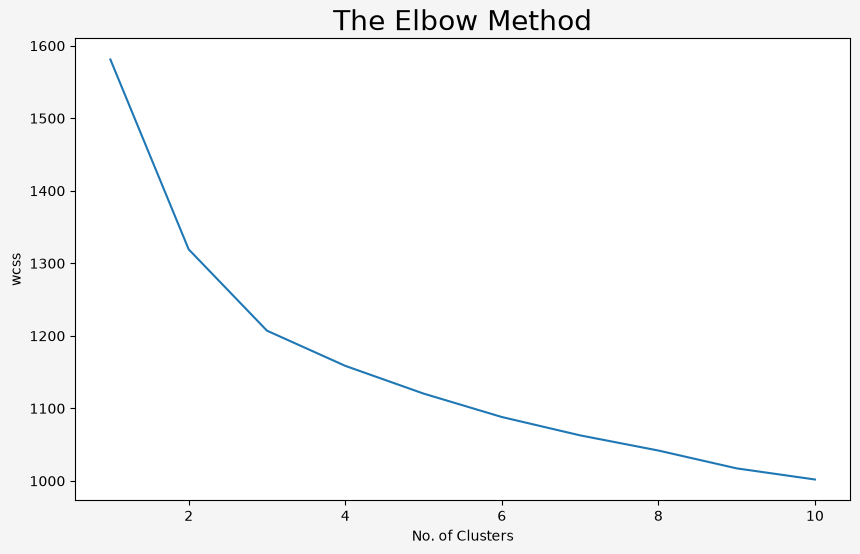

In [72]:
wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    km.fit(X_weighted)
    wcss.append(km.inertia_)
fig=plt.figure(figsize=(10,6))  
fig.patch.set_facecolor('#f6f5f5')

plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method', fontsize = 20)
plt.xlabel('No. of Clusters')
plt.ylabel('wcss')
plt.show()

Based on the elbow, two or three clusters seem to be the most appropriate choice for our dataset, as the line starts to flatten out after that. Another method to estimate a good value for k is to have a look at the corresponding silhouette plots (https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html). Let's create silhouette plots for different numbers of k from 2 to 7.

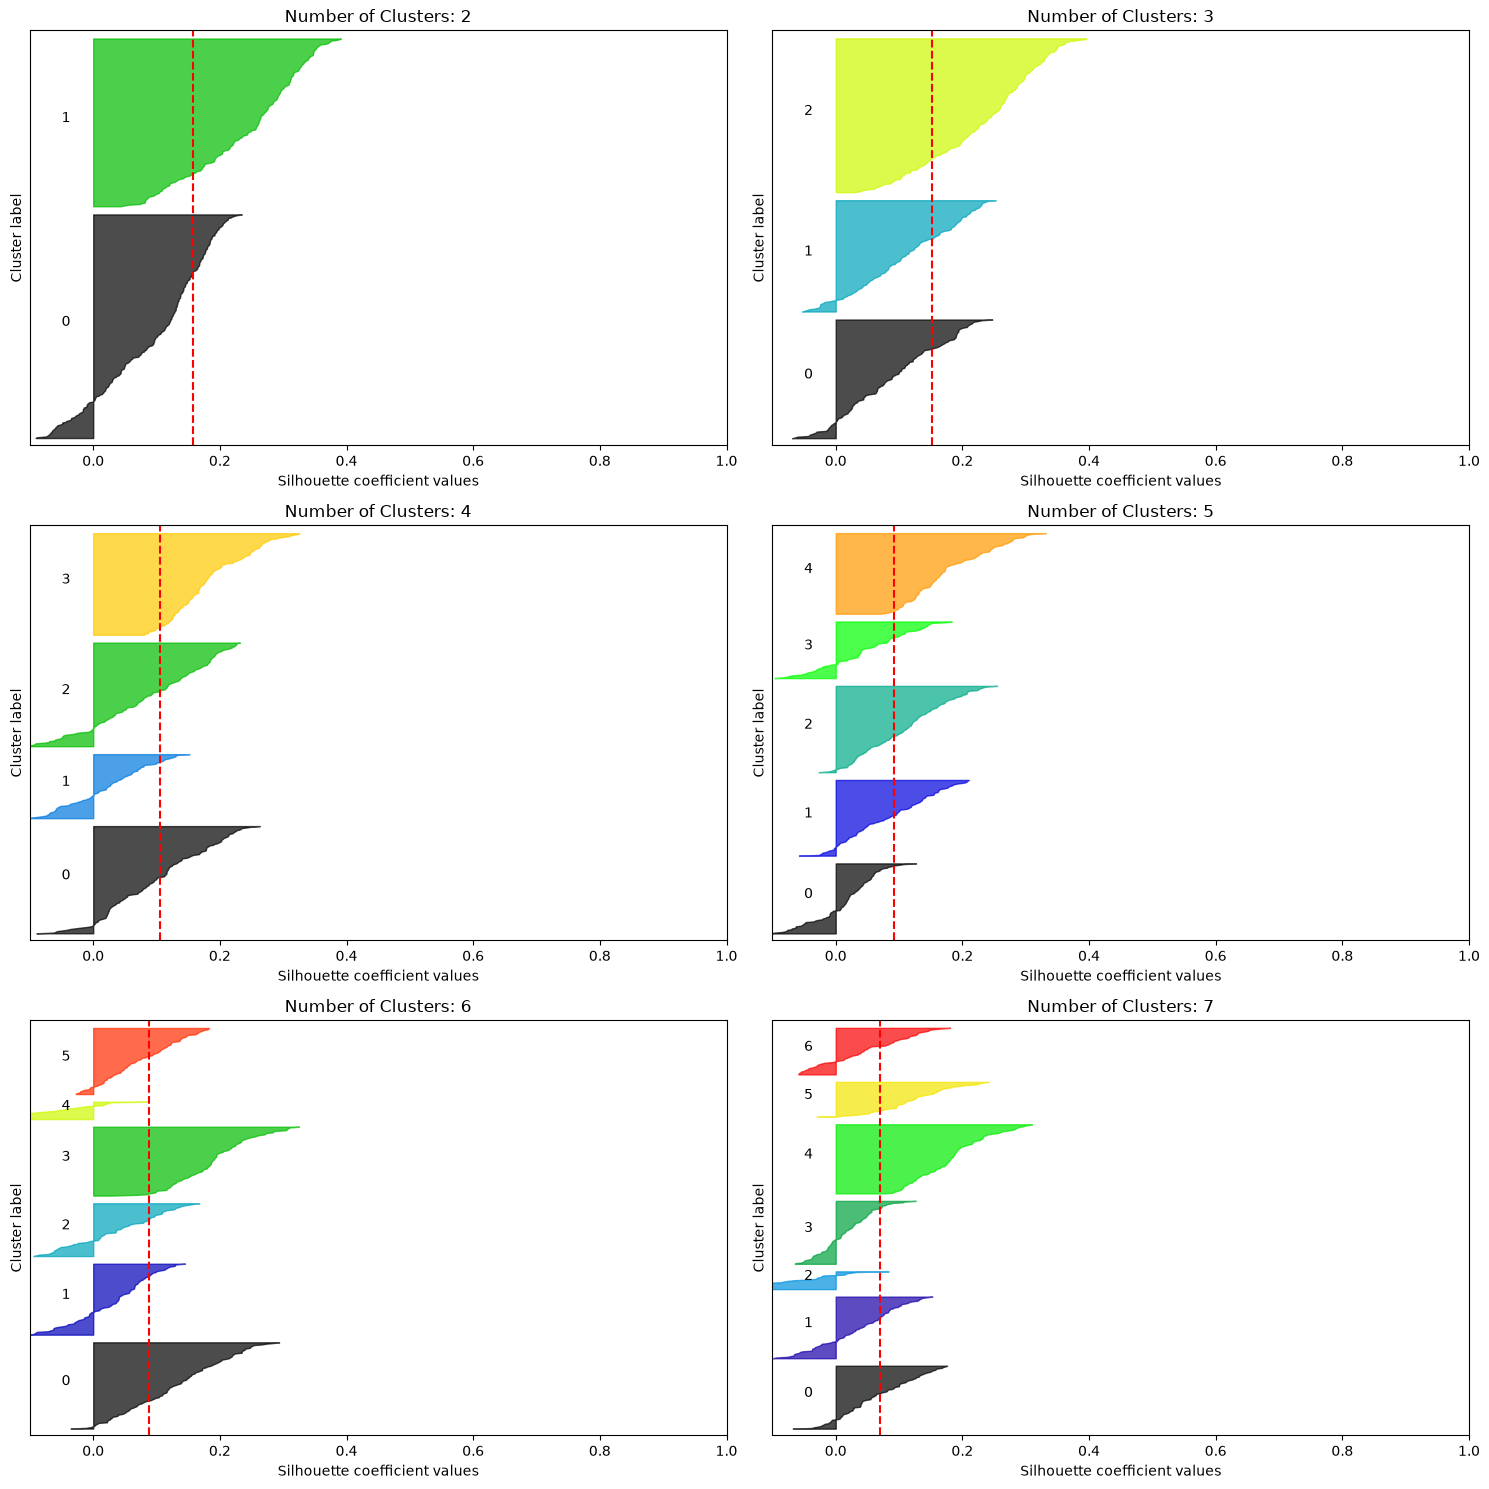

In [73]:
# Range of k values
range_n_clusters = range(2, 8)

# Create a figure to hold the subplots
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()

for k_idx, n_clusters in enumerate(range_n_clusters):
    ax = axes[k_idx]

    # Create a subplot for each k value
    ax.set_xlim([-0.1, 1])
    ax.set_ylim([0, len(X_weighted) + (n_clusters + 1) * 10])

    # Initialize the KMeans algorithm
    kmeans = KMeans(n_clusters = n_clusters, init = 'k-means++', max_iter = 300, n_init = 50, random_state = 0)
    cluster_labels = kmeans.fit_predict(X_weighted)

    # Compute the silhouette scores for each sample
    silhouette_avg = silhouette_score(X_weighted, cluster_labels)
    sample_silhouette_values = silhouette_samples(X_weighted, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.nipy_spectral(float(i) / n_clusters)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values, facecolor=color, edgecolor=color, alpha=0.7)

        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax.set_title(f'Number of Clusters: {n_clusters}')
    ax.set_xlabel("Silhouette coefficient values")
    ax.set_ylabel("Cluster label")
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax.set_yticks([])

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

**Silhouette analysis — choice of k = 3**

- Average scores are low across all k (~0.16 at k=2, ~0.15 at k=3, declining after). This is expected: the PLR form a socioeconomic continuum, not separated clusters, so every k shows points below the average and some negatives. The score can't prove an optimal k here — only rule out poor ones.
- It clearly points to k = 2 or 3: both have the highest scores and healthy cluster shapes (no cluster mostly below zero, balanced widths). k ≥ 5 breaks down — clusters appear almost entirely below zero and sizes fluctuate widely, the classic sign of over-partitioning.
- k = 3 is chosen over k = 2 because the score gap (0.15 vs 0.16) is negligible, k = 2 is too coarse for gentrification.

Let's look at the clusters on a map.

In [74]:
from sklearn.cluster import KMeans

k = 3
km = KMeans(n_clusters=k, init="k-means++", n_init=50, random_state=0)
labels = km.fit_predict(X_weighted)

# Labels zurück an df_model hängen — Reihenfolge stimmt, da nichts umsortiert wurde
df = df.copy()
df["cluster"] = labels
print(df["cluster"].value_counts().sort_index())

cluster
0    163
1    153
2    211
Name: count, dtype: int64


In [75]:
import geopandas as gpd

url = ("https://gdi.berlin.de/services/wfs/lor_2021?service=WFS&version=2.0.0"
       "&request=GetFeature&typeNames=lor_2021:a_lor_plr_2021&outputFormat=application/json")
plr_geo = gpd.read_file(url)

# get plr-id's to strings with len 8
plr_geo["plr_id"] = plr_geo["plr_id"].astype(str).str.zfill(8)
df["plr_id_str"] = df["plr_id"].astype(str).str.zfill(8)

gdf = plr_geo.merge(df[["plr_id_str", "cluster"]],
                    left_on="plr_id", right_on="plr_id_str", how="left")
print("gematcht:", gdf["cluster"].notna().sum(), "von", len(gdf))

gematcht: 527 von 542


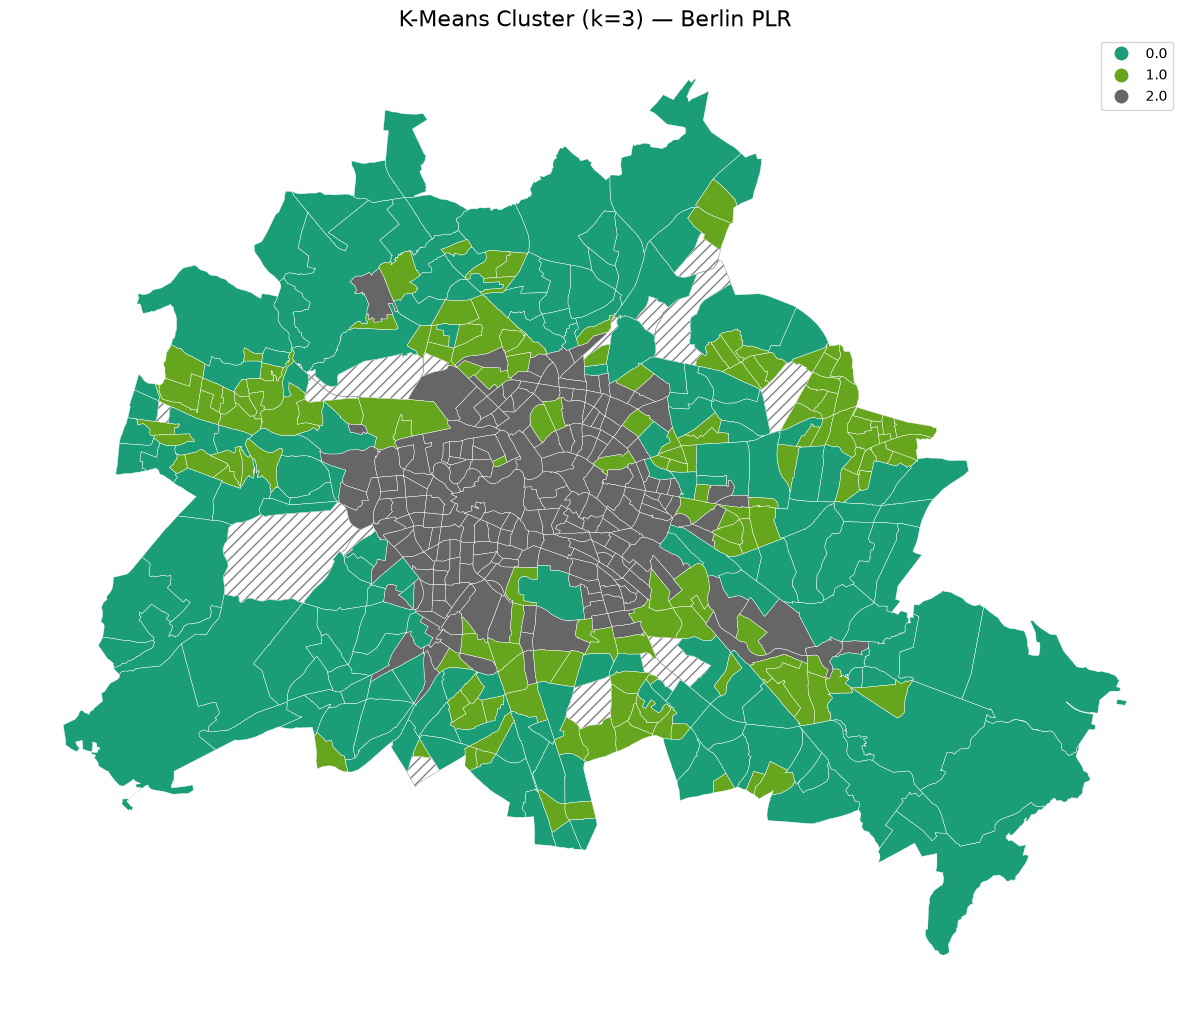

In [76]:
fig, ax = plt.subplots(figsize=(12, 12))

# mark missing PLR's
gdf[gdf["cluster"].isna()].plot(
    ax=ax, color="none", edgecolor="grey", hatch="///", linewidth=0.3, label="no data")

# Add clusters
gdf[gdf["cluster"].notna()].plot(
    column="cluster", categorical=True, legend=True,
    cmap="Dark2", edgecolor="white", linewidth=0.3, ax=ax)

ax.set_title(f"K-Means Cluster (k={k}) — Berlin PLR", fontsize=16)
ax.axis("off"); plt.tight_layout(); plt.show()

The three clusters are geographically clearly separated, which is a strong sign that they capture a real spatial structure rather than statistical noise — the inner-city core, the peripheral ring, and the transition belt between them each form coherent contiguous areas that match Berlin's known centre-periphery geography. Whether the transition belt indicates active upgrading is a question for the cluster profiles. 

### MFA Dataset

Multiple Factor Analysis (MFA) balances variable groups so that no dimension dominates simply by having more variables — it runs a separate PCA per group and normalizes each by its first singular value, unlike a plain PCA where our 19-variable commercial block would outweigh the 9-variable real-estate block. We cluster on the leading MFA components, which capture the structure common to all three dimensions.

The steps here follow the descriptions outlined in the repo by Max Halford for the prince package (https://maxhalford.github.io/prince/mfa/#resources).

In [77]:
#Since prince requires a MultiIndex, the first step is to create that.

def block_of(c):
    if c.startswith("re_"):  return "real_estate"
    if c.startswith("soc_"): return "social"
    return "commercial"

X_mfa = X_imp.copy()   # only imputed as base, MFA standardizes 
X_mfa.columns = pd.MultiIndex.from_tuples([(block_of(c), c) for c in X_mfa.columns])

#check
isinstance(X_mfa.columns, pd.MultiIndex)

True

In [80]:
# The groups are specified by the groups argument when calling fit.
groups = X_mfa.columns.levels[0].tolist()
groups

['commercial', 'real_estate', 'social']

In [81]:
#Next, the MFA is fit
mfa = prince.MFA(
    n_components=3,
    n_iter=3,
    rescale_with_mean=True,
    rescale_with_std=True,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=0
)
mfa = mfa.fit(
    X_mfa,
    groups=groups,
    supplementary_groups=None
)

In [ ]:
#As with PCA, eigenvalues indicate how much variance (inertia) each component captures. 
# The first component represents the direction of maximum consensus across all groups.
mfa.eigenvalues_summary

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,1.885,16.10%,16.10%
1,1.446,12.35%,28.44%
2,0.979,8.35%,36.80%


Row coordinates position each PLR in the space defined by the MFA components. PLRs with similar profiles across all three dimensions will be close together.

It is visible here, that the first three components together capture only 36.8% of the variance. Let's look at a few more components to see how much is needed to capture 80-90% of the variance.

In [85]:
#MFA fit with more components
mfa = prince.MFA(
    n_components=25,
    n_iter=3,
    rescale_with_mean=True,
    rescale_with_std=True,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=0
)
mfa = mfa.fit(
    X_mfa,
    groups=groups,
    supplementary_groups=None
)
mfa.eigenvalues_summary

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,1.885,16.10%,16.10%
1,1.446,12.35%,28.44%
2,0.979,8.35%,36.80%
3,0.669,5.71%,42.51%
4,0.614,5.24%,47.75%
5,0.570,4.87%,52.62%
6,0.419,3.57%,56.19%
7,0.391,3.34%,59.54%
8,0.349,2.98%,62.51%


Reaching 80% requires 18 components, 90% is only reached using 25 components. This flat spread shows the PLRs have no dominant low-dimensional structure — typical of a continuum, not separated clusters. 

With the goal in mind that we want our components to capture the variance that _seperates_ the PLR, a closer look at the table is warranted. Components 6-17 only capture 1-3% variance each, which is most likely an artefact of specific PLRs and not a shared structure of all dimensions. For clustering this is a problem: including these axes adds small random differences to every distance calculation, blurring rather than sharpening the groups. The next step is therefore to find the number of components that retains the shared structure without adding this noise. 

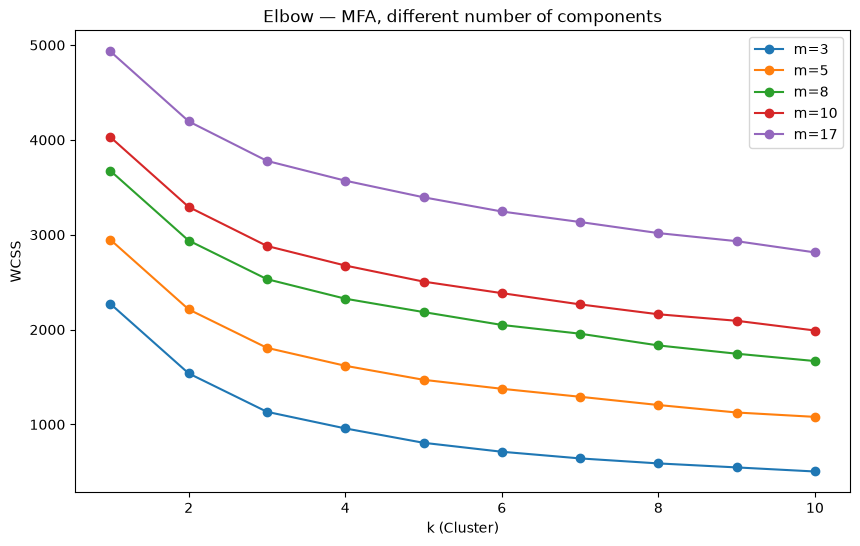

In [100]:
#First, let's use the Elbow method, plotting the optimal k for different values of m

Ks = range(1, 11)
m_values = [3, 5, 8, 10, 17]

plt.figure(figsize=(10, 6))
for m in m_values:
    Xc = X_mfa_coords.iloc[:, :m]
    wcss = []
    for k in Ks:
        km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
        km.fit(Xc)
        wcss.append(km.inertia_)
    plt.plot(Ks, wcss, "o-", label=f"m={m}")

plt.xlabel("k (Cluster)")
plt.ylabel("WCSS")
plt.title("Elbow — MFA, different number of components")
plt.legend()
plt.show()

All five curves show the same elbow at k=2/3, regardless of m — so the choice of k is robust to the number of components. What's still open is m — the elbow varies k, not m, so it can't decide the number of components. So the last remaining piece is a stability analysis for m — which tells us whether m=5 or another m gives the most robust clusters, without falling for the dimensionality artefact.

In [103]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

def subsample_stability(X, k=3, n_runs=30, frac=0.8, random_state=0):
    """
    Mean ARI between the full clustering and clusterings on 80% subsamples.
    High ARI = clusters are robust to which PLRs are included.
    """
    rng = np.random.RandomState(random_state)
    Xv = X.values if hasattr(X, "values") else X

    # reference clustering on all rows
    base = KMeans(k, n_init=10, random_state=0).fit_predict(Xv)

    aris = []
    for _ in range(n_runs):
        idx = rng.choice(len(Xv), int(frac * len(Xv)), replace=False)
        sub = KMeans(k, n_init=10, random_state=0).fit_predict(Xv[idx])
        # compare on the shared rows only
        aris.append(adjusted_rand_score(base[idx], sub))
    return np.mean(aris), np.std(aris)

# --- Question 1: which m gives the most stable MFA clusters? ---
print("MFA — stability by number of components (k=3):")
for m in [3, 4, 5, 6, 8, 10, 17]:
    mean, sd = subsample_stability(X_mfa_coords.iloc[:, :m], k=3)
    print(f"  m={m:2d}: mean ARI = {mean:.3f}  (±{sd:.3f})")

MFA — stability by number of components (k=3):
  m= 3: mean ARI = 0.985  (±0.011)
  m= 4: mean ARI = 0.975  (±0.016)
  m= 5: mean ARI = 0.975  (±0.014)
  m= 6: mean ARI = 0.973  (±0.015)
  m= 8: mean ARI = 0.969  (±0.017)
  m=10: mean ARI = 0.962  (±0.024)
  m=17: mean ARI = 0.953  (±0.026)


Cluster stability is high and nearly flat across all component counts (ARI 0.95–0.99), decreasing only marginally as more components are added — confirming that later components contribute noise rather than stabilising structure. Since stability alone does not sharply favour any m, the choice also considers dimensional representation: m=3 (36.8% variance) risks under-representing one of the three balanced dimensions, so m=5 was chosen as the point that retains near-maximal stability (ARI 0.975) while capturing more of the shared structure across all three dimensions (52.6% variance).

In [102]:
# --- Question 2: MFA (best m) vs. block weighting ---
print("\nMethod comparison (stability, k=3):")
mean_mfa, sd_mfa = subsample_stability(X_mfa_coords.iloc[:, :5], k=3)
mean_bw,  sd_bw  = subsample_stability(X_weighted, k=3)
print(f"  MFA (m=5):       {mean_mfa:.3f}  (±{sd_mfa:.3f})")
print(f"  Block weighting: {mean_bw:.3f}  (±{sd_bw:.3f})")


Method comparison (stability, k=3):
  MFA (m=5):       0.975  (±0.014)
  Block weighting: 0.945  (±0.026)


In [87]:
#Let's look at the transformed dataset. 
X_mfa_coords = mfa.row_coordinates(X_mfa)
X_mfa_coords.head(3)

component,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,1.782757,1.500206,1.127916,0.791870,-0.058359,-0.340170,-0.724168,0.491428,0.584750,1.052748,...,0.423794,0.202478,0.550374,0.024565,0.558076,-0.878689,-0.393687,-0.194068,0.247930,-0.190009
1,2.692456,1.459694,0.400396,0.320047,0.623702,-0.989910,-0.192596,-0.111610,-0.362393,-0.864851,...,-0.590534,0.127440,-0.428892,0.054915,0.048712,-0.256363,0.174835,0.345025,0.228152,-0.044076
2,1.909216,0.639036,0.467385,0.441971,1.017584,-0.628486,-0.878849,-0.243542,-0.780363,0.561993,...,0.540359,0.066731,0.250032,-0.047450,-0.119549,-0.011964,-0.305075,-0.187104,-0.263195,0.049069


In [ ]:
#check: shape of dataset stayed the same
print(X_mfa_coords.shape)

(527, 25)


In [ ]:
#Look at individual contributions to the components 
mfa.group_contributions_.style.format('{:.0%}')

component,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24
group,,,,,,,,,,,,,,,,,,,,,,,,,
commercial,22%,44%,10%,26%,53%,41%,21%,13%,31%,30%,42%,68%,36%,35%,53%,55%,55%,83%,76%,70%,69%,73%,75%,32%,47%
real_estate,47%,13%,3%,19%,2%,18%,28%,31%,40%,22%,14%,20%,32%,29%,12%,7%,5%,7%,13%,12%,8%,10%,5%,20%,15%
social,31%,43%,87%,56%,45%,41%,50%,55%,29%,48%,44%,12%,33%,36%,35%,38%,39%,10%,11%,18%,23%,16%,20%,48%,38%


Group contributions show what percentage of each component’s variance is explained by each group. They sum to 100% across groups for each component. Here, the real estate dimension contributes more to component 0 than the other seasons, meaning this component captures structure that is particularly prominent in that dimension.